In [1]:
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

players = pd.read_csv('core/People.csv')
teams = pd.read_csv('core/Teams.csv')
appearances = pd.read_csv('core/Appearances.csv')
batting = pd.read_csv('core/Batting.csv')

### How loyal are players to a particular team?

We use the number of different teams for with a single player ever played for as a naive quantifier for loyalty. The histogram shows that among all players in the dataset, it is most common for a single player to play for only one team. The number of players playing for two or more teams decreases roughly geometrically.

<Axes: xlabel='numTeams', ylabel='Count'>

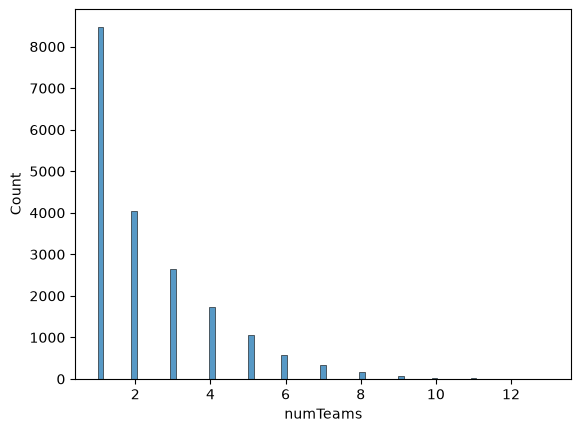

In [2]:
num_teams_per_player = appearances.groupby('playerID')['teamID'].nunique().rename("numTeams")
sns.histplot(x=num_teams_per_player)

### Are players with more career teams more competitive?

Here, we use batting average to roughly quantify how "competitive" a players is. We graph box plots to show how the distribution of batting averages differs based on the number of teams a player has played for.

<Axes: xlabel='numTeams', ylabel='battingAvg'>

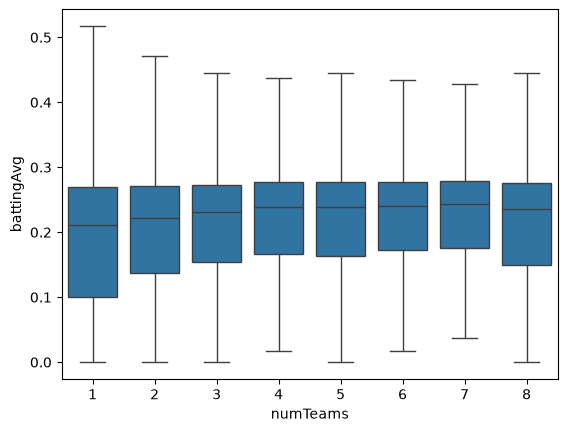

In [3]:
batting['battingAvg'] = batting['H'] / batting['AB']

career_team_perf = pd.merge(batting, num_teams_per_player, on='playerID')[['playerID', 'numTeams', 'battingAvg']]
sns.boxplot(x='numTeams', y='battingAvg', data=career_team_perf[career_team_perf['numTeams'] <= 8], showfliers=False)

To determine if there is a statistically significant difference between the batting averages of players who played for one team versus players who played for four teams, we perform a two-sample t-test.

In [4]:
one_team_perf = career_team_perf[career_team_perf['numTeams'] == 1]['battingAvg']
four_team_perf = career_team_perf[career_team_perf['numTeams'] == 4]['battingAvg']

_, p_value = stats.ttest_ind(one_team_perf, four_team_perf, nan_policy='omit')

print(f"p-value: {p_value}")

p-value: 1.9329285578543515e-49


### Does playing for more teams impact pay?

<Axes: xlabel='numTeams', ylabel='avgSalary'>

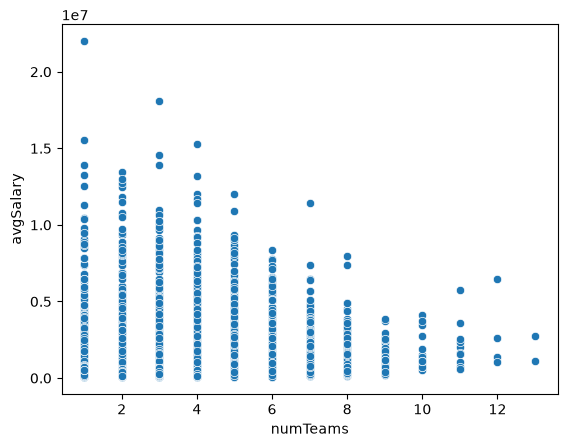

In [5]:
salary = pd.read_csv('core/Salaries.csv')
# Compute average career salary per player
avg_salary = salary.groupby('playerID')['salary'].mean().rename("avgSalary")

# Merge with loyalty metric (numTeams) computed earlier
loyalty_salary = pd.merge(num_teams_per_player, avg_salary, on='playerID')
# Scatterplot: does playing for more teams relate to average salary?
sns.scatterplot(data=loyalty_salary, x='numTeams', y='avgSalary')

<Axes: xlabel='numTeams', ylabel='avgSalary'>

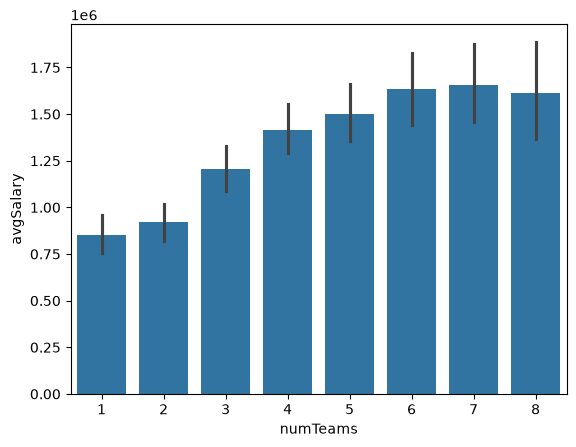

In [6]:
# Bar chart: average salary by number of teams played for
sns.barplot(data=loyalty_salary[loyalty_salary['numTeams'] <= 8], x='numTeams', y='avgSalary')

### Has pay increased over time?

<Axes: xlabel='yearID', ylabel='salary'>

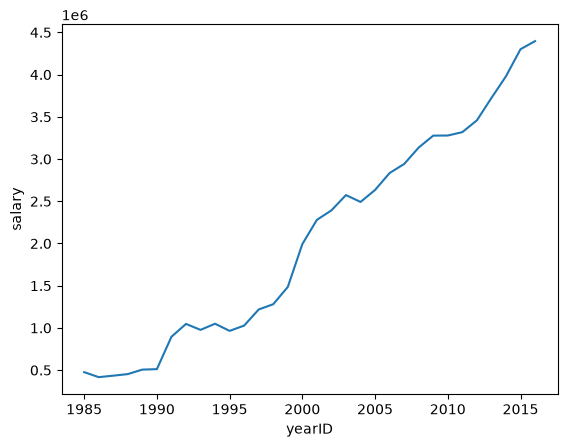

In [7]:
# Line chart: how average MLB salary has trended over the years
salary_by_year = salary.groupby('yearID')['salary'].mean()
sns.lineplot(x=salary_by_year.index, y=salary_by_year)

<Axes: xlabel='yearID', ylabel='maxSalary'>

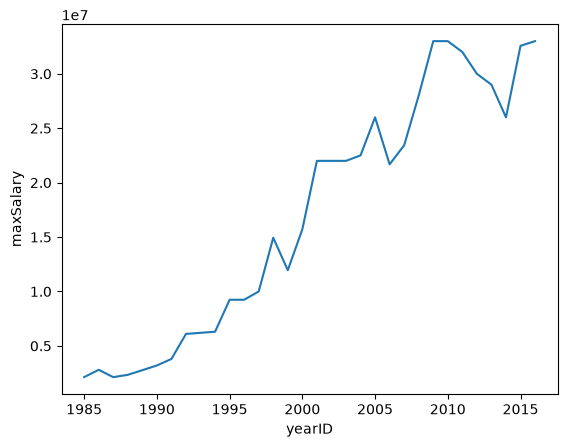

In [8]:
# Highest salary over the years (trend of the salary ceiling)
max_salary_by_year = salary.groupby('yearID')['salary'].max().rename('maxSalary')
sns.lineplot(x=max_salary_by_year.index, y=max_salary_by_year)

### What are the relationships between loyalty, performance, and salary?

<Axes: >

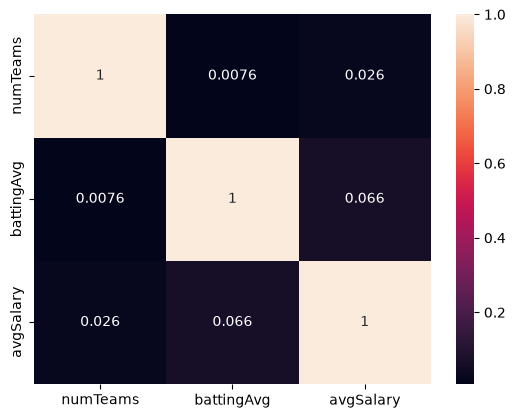

In [9]:
# Correlation heatmap: loyalty, performance, and salary together
three_way = career_team_perf.merge(avg_salary, on='playerID')
correlation = three_way[['numTeams','battingAvg','avgSalary']].corr()
sns.heatmap(correlation, annot=True)

### Which teams pay the most?

<Axes: xlabel='teamID', ylabel='avgSalary'>

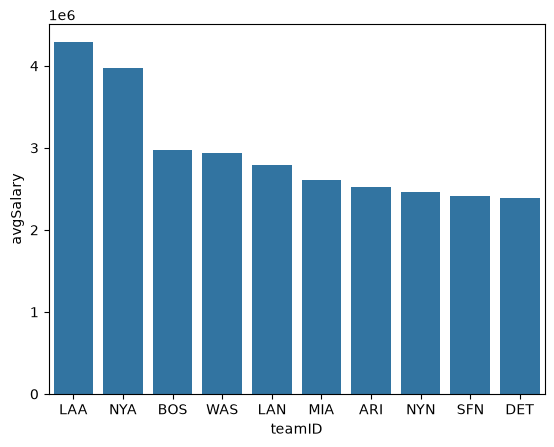

In [10]:
# Which teams have the highest-earning players on average
team_avg_salary = salary.groupby('teamID')['salary'].mean().rename('avgSalary').sort_values(ascending=False)
sns.barplot(x=team_avg_salary.head(10).index, y=team_avg_salary.head(10))

<Axes: xlabel='age', ylabel='Count'>

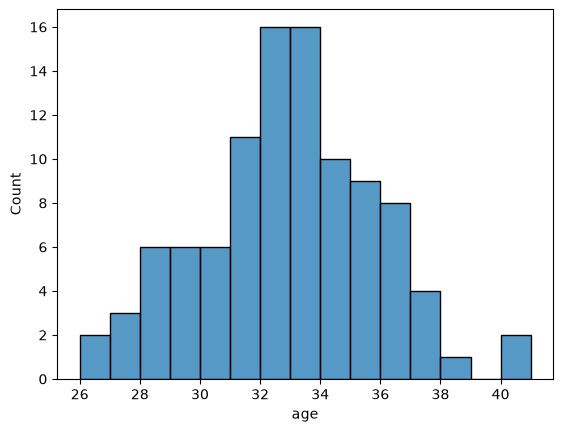

In [11]:
# Merge in birth year to calculate player age at the time of each salary
salary_age = pd.merge(salary, players[['playerID','birthYear']], on='playerID')
salary_age['age'] = salary_age['yearID'] - salary_age['birthYear']

# Look at the age distribution among the top 100 highest-paid salary entries
top_earners = salary_age.sort_values('salary', ascending=False).head(100)
sns.histplot(x=top_earners['age'], bins=15)

Highest: 33000000
Lowest: 0
Median: 550000.0


<Axes: xlabel='salary_range', ylabel='count'>

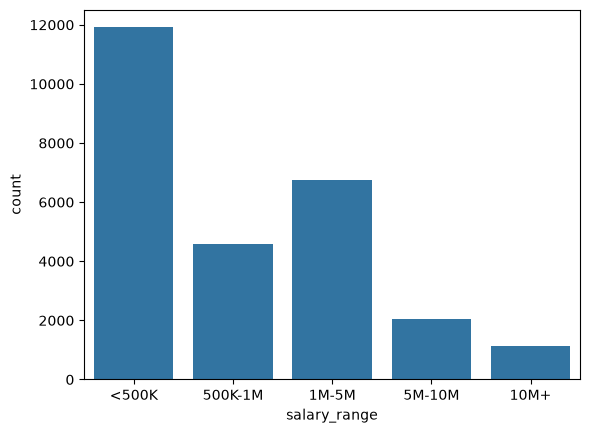

In [12]:
# Salary distribution summary: highest, lowest, median
print("Highest:", salary['salary'].max())
print("Lowest:", salary['salary'].min())
print("Median:", salary['salary'].median())

# Bucket salaries into ranges to see how many players fall in each bracket
# bucket into ranges
bins = [0, 500000, 1000000, 5000000, 10000000, salary['salary'].max()]
labels = ['<500K', '500K-1M', '1M-5M', '5M-10M', '10M+']
salary['salary_range'] = pd.cut(salary['salary'], bins=bins, labels=labels)

sns.countplot(x='salary_range', data=salary)

In [13]:
salary_sorted = salary.sort_values(by='yearID', inplace=False)

# Drop rows with zero or missing salary before computing pct_change
salary_clean = salary_sorted[salary_sorted['salary'] > 0].copy()

salary_clean['salary_change'] = salary_clean.groupby('playerID')['salary'].pct_change()
salary_clean['prev_teamID'] = salary_clean.groupby('playerID')['teamID'].shift()
salary_clean['prev_yearID'] = salary_clean.groupby('playerID')['yearID'].shift()
salary_clean['team_changed'] = salary_clean['prev_teamID'].notna() & (salary_clean['prev_teamID'] != salary_clean['teamID'])
salary_clean['team_changed_offseason'] = salary_clean['team_changed'] & (salary_clean['prev_yearID'] != salary_clean['yearID'])

switch_raise = salary_clean[salary_clean['team_changed_offseason']]['salary_change'].mean()
stay_raise = salary_clean[~salary_clean['team_changed']]['salary_change'].mean()

print(f"Avg raise when switching teams (in the offseason): {switch_raise:.2%}")
print(f"Avg raise when staying with the same team: {stay_raise:.2%}")

Avg raise when switching teams (in the offseason): 33.03%
Avg raise when staying with the same team: 67.20%


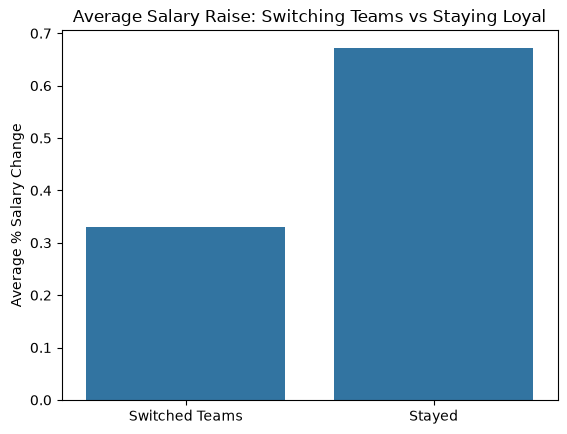

In [14]:
# Bar chart comparing average raise: switching teams vs staying
sns.barplot(x=['Switched Teams', 'Stayed'], y=[switch_raise, stay_raise])
plt.title('Average Salary Raise: Switching Teams vs Staying Loyal')
plt.ylabel('Average % Salary Change')
plt.show()

<Axes: xlabel='age', ylabel='avgSalary'>

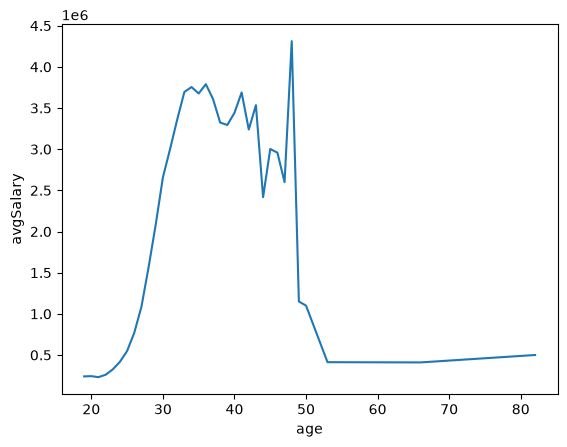

In [15]:
# Salary aging curve — how does pay change with age?

# Average salary at each age (using salary_age from earlier, which has age per salary entry)
avg_salary_by_age = salary_age.groupby('age')['salary'].mean().rename('avgSalary')

# Line chart showing how average salary rises/falls across a player's career
sns.lineplot(x=avg_salary_by_age.index, y=avg_salary_by_age)